# Cuaderno de reproducción íntegra: del corpus a los resultados

Este cuaderno acompaña al TFM como documento de reproducibilidad. Regenera todo el análisis partiendo únicamente de las fuentes públicas: descarga el corpus EPIC v2.0 desde Zenodo, construye el subcorpus de pares original (EN) e interpretación (ES), lo puntúa con los tres procedimientos descritos en la metodología (análisis de
sentimiento con pysentimiento, detección de afecto con el léxico NRC EmoLex y evaluación basada en connotación con el léxico NRC VAD) y termina con las palabras clave (keyness), las colocaciones y las concordancias bilingües que sirven de apoyo al análisis cualitativo.

El código de cada módulo no se importa de fuera: está escrito a la vista, dentro del propio cuaderno, en celdas `%%writefile`. Así cualquiera que lo lea puede seguir el recorrido completo sin salir de aquí, y comprobar que los resultados no dependen de nada oculto. La estructura sigue cuatro pasos: (0) datos de partida, (1) código de los
módulos, (2) ejecución del pipeline y (3) análisis.

Conviene avisar a quien lo ejecute de que el cuaderno descarga los datos y reejecuta los modelos, de modo que tarda (sobre todo el paso de pysentimiento; en Colab
conviene activar la GPU). A cambio, reproduce el análisis completo desde el corpus, sin depender de ningún dato precalculado.

## Paso 0. Datos de partida

### 0.1 Dependencias

In [1]:
# Instalamos pysentimiento (el resto del pipeline funciona solo con librerías estándar)
!pip -q install pysentimiento

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 46.3 MB/s eta 0:00:00


### 0.2 Corpus EPIC v2.0
La siguiente celda descarga de Zenodo solo las partes de texto (metadatos, transcripciones y alineaciones);
el resto del corpus son audio y vídeo que no serán necesarios (y que además pesan más de 7,5 GB).

Licencia CC-BY-NC 4.0 (Lobascio et al., 2024; https://doi.org/10.5281/zenodo.13856205).

In [2]:
import os, urllib.request, zipfile, shutil
BASE = "https://zenodo.org/records/13856205/files/{}?download=1"
PARTS = {"04_metadata_v2.0.zip":"metadata",
         "05_transcripts_v2.0.zip":"transcripts",
         "08_alignments_v2.0.zip":"alignments"}
os.makedirs("epic", exist_ok=True)
for zipname, parent in PARTS.items():
    dest = os.path.join("epic", parent); os.makedirs(dest, exist_ok=True)
    try:
        if not os.path.exists(zipname):
            print("Descargando", zipname, "..."); urllib.request.urlretrieve(BASE.format(zipname), zipname)
        with zipfile.ZipFile(zipname) as z: z.extractall(dest)
        print("  extraído en", dest)
    except Exception as e:
        print(f"  ERROR con {zipname}: {e}\n  Descárgalo a mano desde el registro de Zenodo y súbelo a la carpeta de trabajo.")
# Limpiamos los restos de compresión en Mac
for root, dirs, _ in os.walk("epic"):
    for d in list(dirs):
        if d == "__MACOSX": shutil.rmtree(os.path.join(root, d), ignore_errors=True)
# Comprobamos que el JSON de metadatos quedó en su ruta antes de seguir
mj = "epic/metadata/04_metadata_v2.0/EPIC_v2.0_metadata.json"
print("\nMetadatos en su sitio:", os.path.exists(mj))

Descargando 04_metadata_v2.0.zip ...
  extraído en epic/metadata
Descargando 05_transcripts_v2.0.zip ...
  extraído en epic/transcripts
Descargando 08_alignments_v2.0.zip ...
  extraído en epic/alignments

Metadatos en su sitio: True


### 0.3 Léxicos NRC
Los léxicos no se pueden redistribuir, así que hay que descargarlos de la web de Saif
Mohammad (EmoLex: http://saifmohammad.com/WebPages/NRC-Emotion-Lexicon.htm; VAD:
https://saifmohammad.com/WebPages/nrc-vad.html).

IMPORTANTE: Del VAD hace falta la versión 1, que es
la que incluye la traducción al español; la 2.1 no la incluye.

La celda siguiente pide subir los dos zips (`NRC-Emotion-Lexicon.zip` y `NRC-VAD-Lexicon.zip`)
y los descomprime donde toca. Si ya están en la carpeta de trabajo, los detecta sin pedir nada.

In [3]:
import os, glob, zipfile
TARGETS = ["nrc/emolex/NRC-Emotion-Lexicon/OneFilePerLanguage/Spanish-NRC-EmoLex.txt",
           "nrc/vad/NRC-VAD-Lexicon/OneFilePerLanguage/Spanish-NRC-VAD-Lexicon.txt"]

def colocar_zips():
    for z in glob.glob("*.zip"):
        low = z.lower()
        dest = "nrc/emolex" if ("emolex" in low or "emotion" in low) else ("nrc/vad" if "vad" in low else None)
        if not dest: continue
        os.makedirs(dest, exist_ok=True)
        with zipfile.ZipFile(z) as f: f.extractall(dest)
        print("  descomprimido", z, "->", dest)

if all(os.path.exists(p) for p in TARGETS):
    print("Léxicos NRC ya localizados.")
else:
    colocar_zips()                                   # 1) intenta con zips ya presentes
    if not all(os.path.exists(p) for p in TARGETS):  # 2) si faltan y estamos en Colab, pídelos
        try:
            from google.colab import files
            print("Sube NRC-Emotion-Lexicon.zip y NRC-VAD-Lexicon.zip:")
            files.upload(); colocar_zips()
        except Exception as e:
            print("Súbelos a mano a la carpeta de trabajo. Detalle:", e)

print("\nComprobación:")
for p in TARGETS:
    print(("  OK    " if os.path.exists(p) else "  FALTA ") + p)

Sube NRC-Emotion-Lexicon.zip y NRC-VAD-Lexicon.zip:


Saving NRC-Emotion-Lexicon.zip to NRC-Emotion-Lexicon.zip
Saving NRC-VAD-Lexicon.zip to NRC-VAD-Lexicon.zip
  descomprimido NRC-VAD-Lexicon.zip -> nrc/vad
  descomprimido NRC-Emotion-Lexicon.zip -> nrc/emolex

Comprobación:
  OK    nrc/emolex/NRC-Emotion-Lexicon/OneFilePerLanguage/Spanish-NRC-EmoLex.txt
  OK    nrc/vad/NRC-VAD-Lexicon/OneFilePerLanguage/Spanish-NRC-VAD-Lexicon.txt


## Paso 1. El código del análisis

El código del análisis está organizado en módulos independientes en lugar de en un único bloque de instrucciones. Cada archivo se corresponde con una fase del procesamiento: la construcción del subcorpus a partir de EPIC, la puntuación mediante el léxico NRC, la puntuación con pysentimiento, el ensamblado y la agregación de los resultados, y los instrumentos de apoyo al análisis cualitativo (keyness, colocaciones y concordancias)

Esta organización modular facilita la lectura y la revisión del código, permite reutilizar un mismo componente sin duplicar código y, ante un error, lo acota a un archivo concreto en lugar de a todo el conjunto.

**`epic_pipeline.py`** — Preparación del subcorpus (emparejado, deduplicación, filtros, limpieza, segmentación).

Carga los metadatos de EPIC v2.0, empareja cada discurso original (EN) con su interpretación (ES), aplica los criterios de delimitación del subcorpus (longitud mínima y eje temático) y deja los textos listos para el análisis: limpia las convenciones de transcripción oral (pausas, vacilaciones y similares) y divide cada texto en segmentos, que son la unidad de análisis.




In [4]:
%%writefile epic_pipeline.py
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Preparación del subcorpus EPIC v2.0 (inglés -> español) para el TFM.

Lo que hace, en orden: carga los metadatos y empareja cada original con su
interpretación (vía source_text_id, con deduplicación), aplica los filtros
del subcorpus (tema por specific_topic y longitud mínima, apartado 4.3.2),
limpia las convenciones de oralidad de EPIC, segmenta por '//' añadiendo las
marcas de tiempo de los ficheros de alineación, y exporta dos CSV (uno por
segmento y otro por discurso).

El scoring real (NRC + pysentimiento) no se hace aquí sino en epic_assemble.py.
Este script solo incluye un mini-léxico de prueba (LexiconScorer) que usé al
principio para comprobar que el pipeline funcionaba de punta a punta; la
columna 'polarity' que genera es de control y no se usa en el análisis.
"""

import os
import re
import csv
import json
import html
import glob
import statistics
from collections import defaultdict, Counter

# ------------------------------------------------------------------ CONFIG ----
EPIC_ROOT = "epic"
META_PATH = os.path.join(EPIC_ROOT, "metadata/04_metadata_v2.0/EPIC_v2.0_metadata.json")
SRC_TXT_DIR = os.path.join(EPIC_ROOT, "transcripts/05_transcripts_v2.0/source")
TGT_TXT_DIR = os.path.join(EPIC_ROOT, "transcripts/05_transcripts_v2.0/target")
SRC_ALN_DIR = os.path.join(EPIC_ROOT, "alignments/08_alignments_v2.0/source")
TGT_ALN_DIR = os.path.join(EPIC_ROOT, "alignments/08_alignments_v2.0/target")
OUT_DIR = "out"

# --- Criterios de delimitación del subcorpus (apartado 4.3.2 del TFM) ---------
MIN_SOURCE_TOKENS = 150          # excluye trámite, intervenciones de un minuto, etc.

# EJE TEMÁTICO ELEGIDO:
#   "Discurso político institucional de alto nivel en el Parlamento Europeo:
#    acción exterior y dirección estratégica de la UE"
# El subcorpus se delimita por `specific_topic` (nivel de DISCURSO, fiable),
# NO por `topic_domain` (nivel de SESIÓN, contaminado). Cada tema se asigna a
# un estrato, que se conserva como variable de análisis:
#   Estrato I  -> Acción exterior y conflicto
#   Estrato II -> Consejo Europeo y orientación estratégica de la Unión
STRATA = {
    "I": [   # acción exterior y conflicto
        "Situation in the Middle East",
        "Joint initiative for peace",                # cubre las dos variantes de puntuación
        "Afghanistan",
        "Position of the European Union on the hearing",  # CIJ / muro israelí
        "Nuclear disarmament",
        "EU Policy towards South Caucasus",
        "Elections in Iran",
        "Situation in Kosovo",
        "EU-Russia relations",
        "Political assassinations in Cambodia",
        "Reinvigorating EU actions on human rights",
        "Transatlantic relations",
    ],
    "II": [  # Consejo Europeo y orientación estratégica
        "European Council / Security",
        "European Council/Irish presidency",
        "European Council/Irish Presidency",
        "Preparation of the European Council",
    ],
}

os.makedirs(OUT_DIR, exist_ok=True)


def fix_encoding(s):
    """Repara el mojibake UTF-8 doblemente codificado de algunos `specific_topic`."""
    if not s:
        return s
    try:
        return s.encode("latin1").decode("utf8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return s


def assign_stratum(specific_topic):
    """Devuelve 'I' o 'II' si el tema pertenece al subcorpus; si no, None."""
    topic = (fix_encoding(specific_topic) or "")
    for stratum, prefixes in STRATA.items():
        if any(topic.startswith(p[:30]) for p in prefixes):
            return stratum
    return None


# ----------------------------------------------------- 1) CARGA DE METADATOS --
def load_metadata():
    d = json.load(open(META_PATH, encoding="utf-8"))
    src = {s["source_text_id"]: s for s in d["sourceText"]}
    actors = {a["actor_id"]: a for a in d["actor"]}
    # un evento tiene varias filas (una por dominio temático); las agrupamos
    ev_domains = defaultdict(set)
    ev_date = {}
    for e in d["event"]:
        for t in e.get("topic_domain", []):
            ev_domains[e["event_id"]].add(t)
        ev_date[e["event_id"]] = e.get("event_date")
    return d, src, actors, ev_domains, ev_date


# ------------------------------------------- 2) TABLA DE PARES EN -> ES --------
def build_pairs(meta):
    d, src, actors, ev_domains, ev_date = meta
    rows = []
    seen = set()   # evita pares duplicados por entradas repetidas en los metadatos
    for t in d["targetText"]:
        if t.get("target_language") != ["spa"]:
            continue
        sid = t.get("source_text_id", "")
        if not sid.endswith("org-en"):
            continue
        dedup_key = (sid, t["target_text_id"])
        if dedup_key in seen:
            continue
        seen.add(dedup_key)
        s = src.get(sid)
        if not s:
            continue
        eid = s.get("event_id")
        actor = actors.get(s.get("actor_id"), {})
        domains = sorted(ev_domains.get(eid, []))
        rows.append({
            "speech_id": sid.replace("epic_st_", "").replace("-org-en", ""),
            "source_text_id": sid,
            "target_text_id": t["target_text_id"],
            "src_txt": s["transcript_file_name"],
            "tgt_txt": t["transcript_file_name"],
            "src_aln": s.get("alignment_file_name"),
            "tgt_aln": t.get("alignment_file_name"),
            "date": s.get("source_date"),
            "specific_topic": fix_encoding(s.get("specific_topic")) or "",
            "stratum": assign_stratum(s.get("specific_topic")),
            "topic_domain": "; ".join(domains),
            "speaker": ((actor.get("actor_surname") or "") + ", " +
                        (actor.get("actor_given_name") or "")).strip(", "),
            "speaker_country": actor.get("actor_country") or "",
            "src_tokens": s.get("source_token_gloss_count") or 0,
            "src_duration": s.get("source_duration"),
            "delivery_mode": s.get("delivery_mode"),
        })
    return rows


# ------------------------------------------- 3) FILTROS DEL SUBCORPUS ----------
def passes_filters(row):
    if (row["src_tokens"] or 0) < MIN_SOURCE_TOKENS:
        return False
    if row["stratum"] is None:          # fuera del eje temático elegido
        return False
    return True


# ------------------------------------------- 4) LIMPIEZA DE ORALIDAD -----------
# Convenciones de transcripción de EPIC (ver README del corpus):
#   //              -> límite de segmento (lo usamos para segmentar y lo quitamos)
#   (.) (..) (2.35) -> pausas silenciosas
#   -ehm-  -uhm-    -> pausas llenas (guion + palabra + guion, con espacios)
#   ~malpron </correcto/> -> malpronunciación: nos quedamos con la forma correcta
#   palabra=        -> truncamiento (se elimina el fragmento)
#   _               -> pausa intrapalabra (se une la palabra)
#   ((x)) ((texto)) -> ininteligible / comentario del transcriptor (se elimina)
RE_ENTITY      = re.compile(r"&lt;|&gt;|&amp;")
RE_MISPRON     = re.compile(r"~\S+\s*</\s*([^/>]+?)\s*/>")   # ~xxx </correcto/> -> correcto
RE_STRAY_CORR  = re.compile(r"</\s*([^/>]+?)\s*/>")           # </correcto/> suelto -> correcto
RE_PAUSE_NUM   = re.compile(r"\(\s*\d+(?:\.\d+)?\s*\)")       # (2.35)
RE_PAUSE_DOT   = re.compile(r"\(\s*\.+\s*\)")                 # (.) (..)
RE_FILLED      = re.compile(r"(?<!\S)-\w+-(?!\S)")            # -ehm- como token
RE_DBLPAREN    = re.compile(r"\(\([^)]*\)\)")                 # ((x)) / ((comentario))
RE_TRUNC       = re.compile(r"\b\w+=")                        # pro=
RE_UNDERSCORE  = re.compile(r"_")                             # pausa intrapalabra
RE_WS          = re.compile(r"\s+")

def clean_segment(text):
    t = html.unescape(text)
    t = t.replace("//", " ")
    t = RE_MISPRON.sub(r"\1", t)
    t = RE_STRAY_CORR.sub(r"\1", t)
    t = RE_DBLPAREN.sub(" ", t)
    t = RE_PAUSE_NUM.sub(" ", t)
    t = RE_PAUSE_DOT.sub(" ", t)
    t = RE_FILLED.sub(" ", t)
    t = RE_TRUNC.sub(" ", t)
    t = RE_UNDERSCORE.sub("", t)
    t = t.replace("~", "")
    t = RE_WS.sub(" ", t).strip()
    return t

def read_segments(txt_path, aln_path):
    """Devuelve lista de dicts: {seg_index, start, duration, raw, clean}."""
    raw = open(txt_path, encoding="utf-8").read()
    # tiempos desde el JSON de alineación (alineados al audio del propio texto)
    times = []
    if aln_path and os.path.exists(aln_path):
        try:
            aln = json.load(open(aln_path, encoding="utf-8"))
            times = aln.get("sentences", [])
        except Exception:
            times = []
    segs = [s for s in raw.split("//") if s.strip()]
    out = []
    for i, seg in enumerate(segs):
        clean = clean_segment(seg)
        if not clean:
            continue
        start = times[i]["start"] if i < len(times) else None
        dur = times[i]["duration"] if i < len(times) else None
        out.append({"seg_index": i, "start": start, "duration": dur,
                    "raw": seg.strip(), "clean": clean})
    return out


# ------------------------------------------- 6) SCORER DE PRUEBA ---------------
class LexiconScorer:
    """
    Mini-léxico de prueba con el que validé el pipeline de punta a punta antes
    de conectar los scorers reales (NRC y pysentimiento, en epic_assemble.py).
    Genera una columna 'polarity' de control que el análisis no utiliza.
    """
    POS = {"good","great","support","welcome","peace","progress","hope","right",
           "freedom","democracy","bueno","apoyo","paz","progreso","esperanza",
           "derecho","libertad","democracia","acuerdo","éxito","mejorar"}
    NEG = {"bad","crisis","war","threat","fail","problem","against","danger",
           "violence","corruption","malo","crisis","guerra","amenaza","fracaso",
           "problema","contra","peligro","violencia","corrupción","preocupa"}

    def score(self, text):
        toks = re.findall(r"\w+", text.lower())
        if not toks:
            return {"polarity": 0.0, "n_tokens": 0, "n_hits": 0}
        pos = sum(1 for w in toks if w in self.POS)
        neg = sum(1 for w in toks if w in self.NEG)
        hits = pos + neg
        pol = 0.0 if hits == 0 else (pos - neg) / hits
        return {"polarity": pol, "n_tokens": len(toks), "n_hits": hits}


# ------------------------------------------- 7) AGREGACIÓN Y SALIDA ------------
def mean(xs):
    xs = [x for x in xs if x is not None]
    return round(statistics.mean(xs), 4) if xs else None

def run():
    meta = load_metadata()
    pairs = build_pairs(meta)
    kept = [r for r in pairs if passes_filters(r)]

    scorer = LexiconScorer()
    seg_rows = []        # nivel segmento (tidy)
    speech_rows = []     # nivel discurso (comparación ST vs TT)
    excluded = []        # exclusiones documentadas (criterio técnico, 4.4.1)

    for r in kept:
        src_path = os.path.join(SRC_TXT_DIR, r["src_txt"])
        tgt_path = os.path.join(TGT_TXT_DIR, r["tgt_txt"])
        if not (os.path.exists(src_path) and os.path.exists(tgt_path)):
            excluded.append((r["speech_id"], "falta transcripción"))
            continue
        src_segs = read_segments(src_path, os.path.join(SRC_ALN_DIR, r["src_aln"]))
        tgt_segs = read_segments(tgt_path, os.path.join(TGT_ALN_DIR, r["tgt_aln"]))
        if not src_segs or not tgt_segs:
            excluded.append((r["speech_id"], "sin segmentos válidos tras limpieza"))
            continue

        for role, segs in (("ST", src_segs), ("TT", tgt_segs)):
            for s in segs:
                sc = scorer.score(s["clean"])
                seg_rows.append({
                    "speech_id": r["speech_id"], "stratum": r["stratum"],
                    "role": role, "seg_index": s["seg_index"], "start": s["start"],
                    "duration": s["duration"], "polarity": sc["polarity"],
                    "n_tokens": sc["n_tokens"], "text_clean": s["clean"],
                })

        src_pol = [scorer.score(s["clean"])["polarity"] for s in src_segs]
        tgt_pol = [scorer.score(s["clean"])["polarity"] for s in tgt_segs]
        st_mean, tt_mean = mean(src_pol), mean(tgt_pol)
        delta = (round(tt_mean - st_mean, 4)
                 if (st_mean is not None and tt_mean is not None) else None)
        speech_rows.append({
            **{k: r[k] for k in ("speech_id","stratum","date","specific_topic",
                                 "speaker","speaker_country",
                                 "src_tokens","src_duration")},
            "n_seg_ST": len(src_segs), "n_seg_TT": len(tgt_segs),
            "polarity_ST": st_mean, "polarity_TT": tt_mean,
            "delta_polarity": delta,
        })

    # --- export ---
    seg_csv = os.path.join(OUT_DIR, "epic_en_es_segmentos.csv")
    sp_csv = os.path.join(OUT_DIR, "epic_en_es_discursos.csv")
    with open(seg_csv, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=list(seg_rows[0].keys()))
        w.writeheader(); w.writerows(seg_rows)
    with open(sp_csv, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=list(speech_rows[0].keys()))
        w.writeheader(); w.writerows(speech_rows)

    # --- resumen por consola ---
    by_str = Counter(r["stratum"] for r in speech_rows)
    print(f"Pares EN->ES totales en el corpus : {len(pairs)}")
    print(f"Discursos del eje temático        : {len(kept)} "
          f"(MIN_SOURCE_TOKENS={MIN_SOURCE_TOKENS})")
    print(f"Discursos finales analizados      : {len(speech_rows)} "
          f"[Estrato I: {by_str.get('I',0)} | Estrato II: {by_str.get('II',0)}]")
    print(f"Exclusiones                       : {len(excluded)} {excluded if excluded else ''}")
    print(f"Segmentos analizados (ST+TT)      : {len(seg_rows)}")
    print(f"  - export segmentos -> {seg_csv}")
    print(f"  - export discursos -> {sp_csv}")
    return kept, seg_rows, speech_rows

if __name__ == "__main__":
    run()


Writing epic_pipeline.py


**`nrc_scorer.py`** — Puntuación léxica con los recursos NRC.

Recorre cada segmento y lo puntúa consultando dos diccionarios: EmoLex, que asocia las palabras con emociones básicas y con polaridad positiva o negativa, y VAD, que asigna a cada palabra valores de valencia, activación y dominancia. Es el método basado en lexicón.



In [5]:
%%writefile nrc_scorer.py
# -*- coding: utf-8 -*-
"""
Scorer basado en los léxicos NRC (Mohammad), para inglés y español.

Usa dos recursos, en sus versiones bilingües (un mismo fichero contiene la
palabra inglesa, sus puntuaciones y la traducción española, de modo que ambas
lenguas se miden con entradas y puntuaciones idénticas: máxima comparabilidad):

  - NRC EmoLex  -> 8 emociones (Plutchik) + polaridad positiva/negativa
  - NRC-VAD     -> valencia, activación (arousal) y dominancia [0-1]

Devuelve, por segmento:
  - polarity        : (#pos - #neg) / (#pos + #neg)  en [-1, 1]   (EmoLex)
  - valence/arousal/dominance : medias VAD de las palabras reconocidas
  - emo_<emoción>   : proporción de tokens asociados a cada emoción
  - coverage        : nº de tokens y nº reconocidos en cada léxico
"""
import os, re

NRC_DIR = "nrc"
EMOLEX_ES = os.path.join(NRC_DIR, "emolex/NRC-Emotion-Lexicon/OneFilePerLanguage/Spanish-NRC-EmoLex.txt")
VAD_ES    = os.path.join(NRC_DIR, "vad/NRC-VAD-Lexicon/OneFilePerLanguage/Spanish-NRC-VAD-Lexicon.txt")

EMOTIONS = ["anger","anticipation","disgust","fear","joy","sadness","surprise","trust"]
TOKEN_RE = re.compile(r"[a-záéíóúüñ]+", re.IGNORECASE)


def _load_emolex():
    """English y Spanish word -> dict de emociones/polaridad, desde el fichero bilingüe."""
    en, es = {}, {}
    with open(EMOLEX_ES, encoding="utf-8") as f:
        header = f.readline().rstrip("\n").split("\t")
        # cols: English Word, anger, anticipation, disgust, fear, joy, negative,
        #       positive, sadness, surprise, trust, Spanish Word
        idx = {h: i for i, h in enumerate(header)}
        for line in f:
            p = line.rstrip("\n").split("\t")
            if len(p) < len(header):
                continue
            rec = {k: int(p[idx[k]]) for k in
                   EMOTIONS + ["positive", "negative"]}
            enw = p[idx["English Word"]].strip().lower()
            esw = p[idx["Spanish Word"]].strip().lower()
            if enw:
                en[enw] = rec
            if esw:
                es[esw] = rec
    return en, es


def _load_vad():
    """English y Spanish word -> (valence, arousal, dominance), desde el fichero bilingüe."""
    en, es = {}, {}
    with open(VAD_ES, encoding="utf-8") as f:
        f.readline()  # cabecera: English Word, Valence, Arousal, Dominance, Spanish Word
        for line in f:
            p = line.rstrip("\n").split("\t")
            if len(p) < 5:
                continue
            try:
                v, a, d = float(p[1]), float(p[2]), float(p[3])
            except ValueError:
                continue
            enw, esw = p[0].strip().lower(), p[4].strip().lower()
            if enw:
                en[enw] = (v, a, d)
            if esw:
                es[esw] = (v, a, d)
    return en, es


class NRCScorer:
    _EMO = None
    _VAD = None

    def __init__(self, lang):
        assert lang in ("en", "es")
        self.lang = lang
        if NRCScorer._EMO is None:
            NRCScorer._EMO = _load_emolex()
            NRCScorer._VAD = _load_vad()
        self.emo = NRCScorer._EMO[0 if lang == "en" else 1]
        self.vad = NRCScorer._VAD[0 if lang == "en" else 1]

    def score(self, text):
        toks = TOKEN_RE.findall(text.lower())
        n = len(toks)
        out = {"n_tokens": n, "n_emolex": 0, "n_vad": 0,
               "polarity": 0.0, "valence": None, "arousal": None, "dominance": None}
        for e in EMOTIONS:
            out["emo_" + e] = 0.0
        if n == 0:
            return out
        pos = neg = 0
        emo_counts = {e: 0 for e in EMOTIONS}
        vs = []; ars = []; ds = []
        for w in toks:
            r = self.emo.get(w)
            if r is not None:
                out["n_emolex"] += 1
                pos += r["positive"]; neg += r["negative"]
                for e in EMOTIONS:
                    emo_counts[e] += r[e]
            vad = self.vad.get(w)
            if vad is not None:
                out["n_vad"] += 1
                vs.append(vad[0]); ars.append(vad[1]); ds.append(vad[2])
        out["polarity"] = (pos - neg) / (pos + neg) if (pos + neg) else 0.0
        for e in EMOTIONS:
            out["emo_" + e] = round(emo_counts[e] / n, 4)
        if vs:
            out["valence"] = round(sum(vs) / len(vs), 4)
            out["arousal"] = round(sum(ars) / len(ars), 4)
            out["dominance"] = round(sum(ds) / len(ds), 4)
        return out


if __name__ == "__main__":
    import epic_pipeline as P
    print("Cargando léxicos NRC...")
    sc = {"en": NRCScorer("en"), "es": NRCScorer("es")}
    print("EmoLex EN:", len(sc['en'].emo), "| ES:", len(sc['es'].emo),
          "| VAD EN:", len(sc['en'].vad), "| ES:", len(sc['es'].vad))
    tests = [
        ("en", "this is a dangerous and unacceptable threat to peace and security"),
        ("es", "esto es una amenaza peligrosa e inaceptable para la paz y la seguridad"),
        ("en", "I warmly welcome this excellent and hopeful agreement"),
        ("es", "acojo con satisfacción este acuerdo excelente y esperanzador"),
    ]
    for lang, t in tests:
        r = sc[lang].score(t)
        print(f"\n[{lang}] {t}")
        print(f"   polaridad={r['polarity']:+.2f} valencia={r['valence']} "
              f"arousal={r['arousal']} | cobertura EmoLex {r['n_emolex']}/{r['n_tokens']} "
              f"VAD {r['n_vad']}/{r['n_tokens']}")
        top = sorted(((r['emo_'+e], e) for e in EMOTIONS), reverse=True)[:3]
        print("   emociones top:", ", ".join(f"{e}={v}" for v, e in top if v > 0))


Writing nrc_scorer.py


**`pysent_chunk.py`** — Puntuación con pysentimiento (modelo neuronal preentrenado).

Aplica un modelo de aprendizaje profundo, específico de cada lengua, que estima el sentimiento de cada segmento (positivo, negativo o neutro) sin recurrir a un diccionario. Procesa los textos por bloques y guarda los resultados en una caché, de modo que una interrupción no obliga a empezar de nuevo. Es el paso más lento y conviene ejecutarlo con GPU.

In [13]:
%%writefile pysent_chunk.py
# -*- coding: utf-8 -*-
"""Puntúa con pysentimiento en lotes reanudables. Uso: python3 pysent_chunk.py ROLE MAX
ROLE in {ST,TT}; guarda/append en out/pysent_cache.csv keyed por (role,speech_id,seg_index)."""
import os, csv, sys, time

SEG_CSV = "out/epic_en_es_segmentos.csv"
CACHE = "out/pysent_cache.csv"
LANG = {"ST": "en", "TT": "es"}
FIELDS = ["role","speech_id","seg_index","pysent_label","pysent_pos","pysent_neg","pysent_neu","pysent_polarity"]

def load_done():
    done = set()
    if os.path.exists(CACHE):
        with open(CACHE, encoding="utf-8") as f:
            for r in csv.DictReader(f):
                done.add((r["role"], r["speech_id"], r["seg_index"]))
    return done

def main():
    role = sys.argv[1]; mx = int(sys.argv[2])
    done = {d for d in load_done() if d[0] == role}  # solo las claves de este rol; así el resumen no mezcla ST con TT
    rows = [r for r in csv.DictReader(open(SEG_CSV, encoding="utf-8"))
            if r["role"] == role and (r["role"], r["speech_id"], r["seg_index"]) not in done]
    total_role = sum(1 for r in csv.DictReader(open(SEG_CSV, encoding="utf-8")) if r["role"] == role)
    todo = rows[:mx]
    if not todo:
        print(f"[{role}] nada pendiente. Cacheados {len(done)}.")
        return
    os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")
    from pysentimiento import create_analyzer
    an = create_analyzer(task="sentiment", lang=LANG[role])
    t0 = time.time()
    new = open(CACHE, "a", newline="", encoding="utf-8")
    w = csv.DictWriter(new, fieldnames=FIELDS)
    if os.path.getsize(CACHE) == 0 if os.path.exists(CACHE) else True:
        w.writeheader()
    B = 256
    for b in range(0, len(todo), B):
        chunk = todo[b:b+B]
        preds = an.predict([r["text_clean"] for r in chunk])
        for r, pr in zip(chunk, preds):
            pp = pr.probas
            w.writerow({"role": role, "speech_id": r["speech_id"], "seg_index": r["seg_index"],
                        "pysent_label": pr.output,
                        "pysent_pos": round(pp.get("POS",0),4), "pysent_neg": round(pp.get("NEG",0),4),
                        "pysent_neu": round(pp.get("NEU",0),4),
                        "pysent_polarity": round(pp.get("POS",0)-pp.get("NEG",0),4)})
        new.flush()
    new.close()
    hechos = len(done) + len(todo)
    print(f"[{role}] procesados {len(todo)} en {time.time()-t0:.0f}s. "
          f"Cacheados {hechos}/{total_role}. Pendientes {total_role-hechos}.")

if __name__ == "__main__":
    main()


Overwriting pysent_chunk.py


**`epic_assemble.py`** — Ensamblado y agregación de resultados.

Reúne las puntuaciones de los dos métodos anteriores, las une a la tabla de pares original-interpretación y las agrega por segmento y por par, generando los archivos CSV finales que se utilizan para el posterior análisis.



In [7]:
%%writefile epic_assemble.py
# -*- coding: utf-8 -*-
"""Ensambla los CSV finales puntuados: NRC (recalculado, instantáneo) + pysentimiento
(desde caché) a nivel de segmento, y agregación por discurso con medias ST/TT y deltas."""
import csv, statistics
from nrc_scorer import NRCScorer, EMOTIONS

OUT = "out/"
SEG_IN = OUT + "epic_en_es_segmentos.csv"      # datos (keys + texto limpio)
SP_IN  = OUT + "epic_en_es_discursos.csv"      # metadatos de discurso
CACHE  = OUT + "pysent_cache.csv"

def mean(xs):
    xs = [x for x in xs if x is not None]
    return round(statistics.mean(xs), 4) if xs else None

# pysentimiento desde caché
pys = {}
for r in csv.DictReader(open(CACHE, encoding="utf-8")):
    pys[(r["role"], r["speech_id"], r["seg_index"])] = r

# metadatos de discurso
meta = {r["speech_id"]: r for r in csv.DictReader(open(SP_IN, encoding="utf-8"))}

nrc = {"ST": NRCScorer("en"), "TT": NRCScorer("es")}
seg_rows = []
for r in csv.DictReader(open(SEG_IN, encoding="utf-8")):
    role = r["role"]; key = (role, r["speech_id"], r["seg_index"])
    sc = nrc[role].score(r["text_clean"])
    row = {"speech_id": r["speech_id"], "stratum": r["stratum"], "role": role,
           "seg_index": r["seg_index"], "start": r["start"], "duration": r["duration"],
           "n_tokens": sc["n_tokens"], "nrc_polarity": sc["polarity"],
           "valence": sc["valence"], "arousal": sc["arousal"], "dominance": sc["dominance"],
           "n_emolex": sc["n_emolex"], "n_vad": sc["n_vad"]}
    for e in EMOTIONS:
        row["emo_" + e] = sc["emo_" + e]
    p = pys.get(key, {})
    row["pysent_label"] = p.get("pysent_label")
    row["pysent_polarity"] = float(p["pysent_polarity"]) if p.get("pysent_polarity") not in (None, "") else None
    row["text"] = r["text_clean"]
    seg_rows.append(row)

# agregación por discurso
metrics = ["nrc_polarity", "valence", "arousal", "dominance", "pysent_polarity"]
by = {}
for s in seg_rows:
    by.setdefault((s["speech_id"], s["role"]), []).append(s)

sp_rows = []
for sid, m in meta.items():
    row = {k: m[k] for k in ("speech_id","stratum","date","specific_topic","speaker","speaker_country","src_tokens")}
    st = by.get((sid,"ST"), []); tt = by.get((sid,"TT"), [])
    row["n_seg_ST"] = len(st); row["n_seg_TT"] = len(tt)
    for me in metrics:
        a = mean([x[me] for x in st]); b = mean([x[me] for x in tt])
        row[me+"_ST"], row[me+"_TT"] = a, b
        row[me+"_delta"] = (round(b-a,4) if (a is not None and b is not None) else None)
    # emoción dominante por rol (media de proporciones)
    for role,segs,suf in (("ST",st,"_ST"),("TT",tt,"_TT")):
        if segs:
            avg = {e: mean([x["emo_"+e] for x in segs]) or 0 for e in EMOTIONS}
            row["emo_dom"+suf] = max(avg, key=avg.get)
    sp_rows.append(row)

seg_csv = OUT + "epic_scored_segmentos.csv"
sp_csv  = OUT + "epic_scored_discursos.csv"
seg_cols = ["speech_id","stratum","role","seg_index","start","duration","n_tokens",
            "nrc_polarity","valence","arousal","dominance"]+["emo_"+e for e in EMOTIONS]+\
           ["n_emolex","n_vad","pysent_label","pysent_polarity","text"]
with open(seg_csv,"w",newline="",encoding="utf-8") as f:
    w=csv.DictWriter(f,fieldnames=seg_cols,extrasaction="ignore"); w.writeheader(); w.writerows(seg_rows)
with open(sp_csv,"w",newline="",encoding="utf-8") as f:
    w=csv.DictWriter(f,fieldnames=list(sp_rows[0].keys())); w.writeheader(); w.writerows(sp_rows)
print(f"OK: {len(seg_rows)} segmentos -> {seg_csv}")
print(f"OK: {len(sp_rows)} discursos -> {sp_csv}")


Writing epic_assemble.py


**`epic_keywords.py`** — Instrumentos de apoyo al análisis cualitativo.

Calcula las palabras clave por keyness (log-likelihood) frente a un corpus de referencia, las colocaciones de un término dado (log-Dice e información mutua) y las concordancias bilingües (cada aparición de una palabra en su contexto, junto al fragmento equivalente en la otra lengua). Este paso no constituye una capa cuantitativa independiente: sirve para localizar y acotar los segmentos sobre los que se realiza después la interpretación cualitativa.


In [33]:
%%writefile epic_keywords.py
# -*- coding: utf-8 -*-
"""
Instrumentos de apoyo al análisis cualitativo del TFM: palabras clave,
colocaciones y concordancias (apartado 4.4.4).

  - keyness: razón de verosimilitud (log-likelihood) del subcorpus inglés (ST)
    frente al resto de EPIC inglés (referencia interna). Dunning (1993);
    Rayson y Garside (2000).
  - colocaciones: log-Dice e información mutua (MI) en una ventana de contexto.
    Sinclair (1991); para la prosodia semántica, Stubbs (2001).
  - concordancias (KWIC): apariciones del término en contexto en el original,
    con el segmento alineado de la interpretación (por marcas temporales, 4.4.1).

El keyness se calcula solo dentro del inglés; los términos se rastrean después
en la interpretación de forma cualitativa.
"""
import csv, re, math, collections

TOKEN_RE = re.compile(r"[a-záéíóúüñ']+", re.IGNORECASE)

# lista breve de palabras vacías inglesas, para la vista de "palabras clave de contenido"
STOPWORDS_EN = set("""a an the this that these those of to in on at by for with from into about
and or but nor so yet as if than then because while when where which who whom whose what
i you he she it we they me him her us them my your his its our their mine yours ours theirs
is are was were be been being am do does did doing have has had having will would shall should
can could may might must not no nor very more most much many few some any all both each
here there now also just only own same such own up down out off over under again further once
do does s t re ve ll d m o""".split())


def tokenize(text):
    return TOKEN_RE.findall(text.lower())


def load_segments(seg_csv):
    """Lee el CSV de segmentos puntuados: speech_id, role, seg_index, start, duration, text."""
    segs = []
    with open(seg_csv, encoding="utf-8") as f:
        for r in csv.DictReader(f):
            segs.append({"speech_id": r["speech_id"], "role": r["role"],
                         "seg_index": int(r["seg_index"]),
                         "start": float(r["start"]) if r.get("start") not in (None, "") else None,
                         "duration": float(r["duration"]) if r.get("duration") not in (None, "") else None,
                         "text": r["text"]})
    return segs


def freq_from_segments(segments, role):
    c = collections.Counter(); total = 0
    for s in segments:
        if s["role"] != role:
            continue
        toks = tokenize(s["text"]); c.update(toks); total += len(toks)
    return c, total


def load_reference_freq(path):
    """Lee out/epic_en_reference_freq.csv (word, freq) con fila __TOTAL__."""
    c = collections.Counter(); total = 0
    with open(path, encoding="utf-8") as f:
        for r in csv.reader(f):
            if r[0] == "word" or not r:
                continue
            if r[0] == "__TOTAL__":
                total = int(r[1]); continue
            c[r[0]] = int(r[1])
    return c, total


def _ll(a, b, c, d):
    """Log-likelihood (Rayson). a=freq target, b=freq ref, c=total target, d=total ref."""
    e1 = c * (a + b) / (c + d)
    e2 = d * (a + b) / (c + d)
    g = 0.0
    if a > 0:
        g += a * math.log(a / e1)
    if b > 0:
        g += b * math.log(b / e2)
    return 2 * g


def keyness(target_freq, target_total, ref_freq, ref_total,
            min_freq=3, content_only=True, top=40):
    """Devuelve las palabras clave del target frente a la referencia, ordenadas por log-likelihood."""
    rows = []
    for w, a in target_freq.items():
        if a < min_freq:
            continue
        if content_only and (w in STOPWORDS_EN or len(w) <= 2):
            continue
        b = ref_freq.get(w, 0)
        ll = _ll(a, b, target_total, ref_total)
        sign = "+" if (a / target_total) > (b / ref_total if ref_total else 0) else "-"
        rows.append({"word": w, "ll": round(ll, 2), "sign": sign,
                     "f_sub": a, "f_ref": b,
                     "per10k_sub": round(a / target_total * 10000, 1),
                     "per10k_ref": round(b / ref_total * 10000, 1) if ref_total else 0.0})
    rows.sort(key=lambda r: r["ll"], reverse=True)
    # solo sobrerrepresentadas (signo +), que son las "clave" del subcorpus
    rows = [r for r in rows if r["sign"] == "+"]
    return rows[:top] if top else rows


def collocations(segments, node, role="ST", window=5, min_coll_freq=3, top=25):
    """Colocaciones del nodo en los segmentos del rol indicado. Devuelve log-Dice y MI."""
    node = node.lower()
    f_word = collections.Counter(); total = 0
    f_coll = collections.Counter(); f_node = 0
    for s in segments:
        if s["role"] != role:
            continue
        toks = tokenize(s["text"]); total += len(toks); f_word.update(toks)
        idx = [i for i, t in enumerate(toks) if t == node]
        f_node += len(idx)
        for i in idx:
            lo = max(0, i - window); hi = min(len(toks), i + window + 1)
            for j in range(lo, hi):
                if j == i:
                    continue
                f_coll[toks[j]] += 1
    out = []
    for c, fc in f_coll.items():
        if fc < min_coll_freq or c == node:
            continue
        fw = f_word[c]
        log_dice = 14 + math.log2(2 * fc / (f_node + fw)) if (f_node + fw) else float("-inf")
        mi = math.log2(fc * total / (f_node * fw)) if (f_node and fw) else float("-inf")
        out.append({"collocate": c, "f_coll": fc, "f_total": fw,
                    "log_dice": round(log_dice, 2), "mi": round(mi, 2)})
    out.sort(key=lambda r: r["log_dice"], reverse=True)
    return out[:top] if top else out


def _aligned_segment(segments, src, target_role):
    """Devuelve el segmento del rol objetivo (mismo discurso) con mayor solape temporal."""
    if src["start"] is None:
        return None
    s0, s1 = src["start"], src["start"] + (src["duration"] or 0)
    best, best_ov = None, -1
    for s in segments:
        if s["speech_id"] != src["speech_id"] or s["role"] != target_role or s["start"] is None:
            continue
        t0, t1 = s["start"], s["start"] + (s["duration"] or 0)
        ov = min(s1, t1) - max(s0, t0)
        if ov > best_ov:
            best_ov, best = ov, s
    return best


def concordances(segments, node, role="ST", context=6, align=True, max_lines=40):
    """KWIC del nodo en el rol indicado, con el segmento alineado del otro rol si align=True."""
    node = node.lower(); other = "TT" if role == "ST" else "ST"
    lines = []
    for s in segments:
        if s["role"] != role:
            continue
        toks = s["text"].split()
        low = [t.lower().strip(".,;:()") for t in toks]
        for i, t in enumerate(low):
            if t == node:
                left = " ".join(toks[max(0, i - context):i])
                right = " ".join(toks[i + 1:i + 1 + context])
                rec = {"speech_id": s["speech_id"], "seg_index": s["seg_index"],
                       "left": left, "kwic": toks[i], "right": right}
                if align:
                    tt = _aligned_segment(segments, s, other)
                    rec["aligned"] = tt["text"] if tt else "(sin alinear)"
                lines.append(rec)
                if len(lines) >= max_lines:
                    return lines
    return lines


if __name__ == "__main__":
    SEG = "out/epic_scored_segmentos.csv"; REF = "out/epic_en_reference_freq.csv"
    segs = load_segments(SEG)
    tf, tt_total = freq_from_segments(segs, "ST")
    rf, rtotal = load_reference_freq(REF)
    print(f"Subcorpus EN: {tt_total} tokens | Referencia: {rtotal} tokens\n")
    print("=== PALABRAS CLAVE (keyness, top 20 de contenido) ===")
    print(f"{'palabra':16}{'LL':>9}{'f_sub':>7}{'f_ref':>7}{'/10k sub':>9}{'/10k ref':>9}")
    for r in keyness(tf, tt_total, rf, rtotal, top=20):
        print(f"{r['word']:16}{r['ll']:9.1f}{r['f_sub']:7}{r['f_ref']:7}{r['per10k_sub']:9.1f}{r['per10k_ref']:9.1f}")
    print("\n=== COLOCACIONES de 'rights' (top 12 por log-Dice) ===")
    for c in collocations(segs, "rights", top=12):
        print(f"  {c['collocate']:16} log-Dice={c['log_dice']:.2f}  MI={c['mi']:.2f}  (n={c['f_coll']})")
    print("\n=== CONCORDANCIAS de 'rights' (5 líneas, con interpretación alineada) ===")
    for ln in concordances(segs, "rights", max_lines=5):
        print(f"  [{ln['speech_id']}] ...{ln['left'][-40:]} [{ln['kwic']}] {ln['right'][:40]}...")
        print(f"      TT> {ln['aligned'][:90]}")


Overwriting epic_keywords.py


## Paso 2. Ejecución

Ya escrito el código en el paso anterior, aquí se ejecuta en orden. Primero se prepara el subcorpus; después se puntúa con los dos métodos (los léxicos NRC y pysentimiento), se ensamblan los resultados y, por último, se calculan las frecuencias del corpus de referencia que necesita el análisis de palabras clave.

Empezamos por preparar el subcorpus. La primera celda crea la carpeta de salida (`out/`) y ejecuta `epic_pipeline.py`: parte de los metadatos de EPIC, empareja cada discurso
original en inglés con su interpretación al español, aplica los criterios de delimitación (longitud mínima y eje temático), limpia las marcas de transcripción oral y divide los textos en segmentos. Al terminar informa de cuántos pares y discursos componen el subcorpus y de cuántos segmentos resultan, y deja en `out/` dos archivos: uno con los
segmentos y otro con los discursos.

In [9]:
!mkdir -p out
!python epic_pipeline.py

Pares EN->ES totales en el corpus : 305
Discursos del eje temático        : 71 (MIN_SOURCE_TOKENS=150)
Discursos finales analizados      : 71 [Estrato I: 47 | Estrato II: 24]
Exclusiones                       : 0 
Segmentos analizados (ST+TT)      : 4872
  - export segmentos -> out/epic_en_es_segmentos.csv
  - export discursos -> out/epic_en_es_discursos.csv


### Puntuación con pysentimiento

El segundo método de puntuación aplica pysentimiento, un modelo neuronal preentrenado que estima el sentimiento de cada segmento (positivo, negativo o neutro) a partir del texto, sin recurrir a un diccionario. Como el modelo es específico de cada lengua, se ejecuta en dos pasadas: primero sobre los discursos originales en inglés y después sobre las
interpretaciones en español, cada una con su modelo correspondiente.

Es el paso más lento del cuaderno, porque la primera vez descarga los modelos y porque procesa los segmentos uno a uno (de ahí que convenga la GPU). Para que una interrupción no
obligue a repetirlo, va guardando los resultados en una caché a medida que avanza: si Colab se desconecta a mitad, basta con volver a ejecutar la celda y el proceso continúa por donde se había quedado en lugar de empezar de nuevo.

In [14]:
!python pysent_chunk.py ST 100000
!python pysent_chunk.py TT 100000

[ST] nada pendiente. Cacheados 2498.
[TT] nada pendiente. Cacheados 2374.


In [11]:
!python epic_assemble.py

OK: 4872 segmentos -> out/epic_scored_segmentos.csv
OK: 71 discursos -> out/epic_scored_discursos.csv


### Corpus de referencia para las palabras clave

El análisis de palabras clave (keyness) no mide la frecuencia de una palabra en términos absolutos, sino si aparece en el subcorpus mucho más (o mucho menos) de lo esperable. Para
decidir qué es "esperable" hace falta un punto de comparación: un corpus de referencia del mismo tipo de discurso pero ajeno al subcorpus analizado. Esta celda lo construye contando las frecuencias de palabras de los 239 discursos originales en inglés de EPIC que quedan fuera del subcorpus. Se usan los que quedan fuera, y no el corpus entero, para no comparar el subcorpus consigo mismo, lo que rebajaría artificialmente el contraste. El resultado se
guarda en `out/epic_en_reference_freq.csv`, que es el que el módulo de análisis emplea después para determinar qué términos son característicos del subcorpus.

In [12]:
import epic_pipeline as P, glob, os, csv, re, collections
TOKEN_RE = re.compile(r"[a-z']+")
meta = P.load_metadata(); pairs = P.build_pairs(meta)
sub = set(r["source_text_id"] for r in pairs if P.passes_filters(r))
ref = collections.Counter(); ntok = 0
for f in glob.glob(P.SRC_TXT_DIR + "/*org-en.txt"):
    if os.path.basename(f).replace(".txt", "") in sub: continue
    for s in P.read_segments(f, None):
        t = TOKEN_RE.findall(s["clean"].lower()); ref.update(t); ntok += len(t)
with open("out/epic_en_reference_freq.csv", "w", newline="", encoding="utf-8") as fh:
    w = csv.writer(fh); w.writerow(["word", "freq"]); w.writerow(["__TOTAL__", ntok])
    for word, c in ref.most_common(): w.writerow([word, c])
print("Referencia:", ntok, "tokens ->", "out/epic_en_reference_freq.csv")

Referencia: 89741 tokens -> out/epic_en_reference_freq.csv


## Paso 3. Análisis

Con el subcorpus ya puntuado, esta última parte recorre el análisis en dos bloques.

El primero es cuantitativo: describe el subcorpus, compara los discursos originales con sus interpretaciones (prueba de Wilcoxon pareada), desglosa los datos por estrato y mide hasta
qué punto coinciden los dos métodos de puntuación.

El segundo reúne los instrumentos de corpus que apoyan el análisis cualitativo: palabras clave (keyness), colocaciones, concordancias y la selección de los casos que se examinan en detalle. Todo se calcula con el módulo escrito en el paso 1.

In [15]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.stats import wilcoxon, pearsonr
import importlib, epic_keywords as kw; importlib.reload(kw)

seg  = pd.read_csv("out/epic_scored_segmentos.csv")
disc = pd.read_csv("out/epic_scored_discursos.csv")
segments = kw.load_segments("out/epic_scored_segmentos.csv")
st_freq, st_total = kw.freq_from_segments(segments, "ST")
ref_freq, ref_total = kw.load_reference_freq("out/epic_en_reference_freq.csv")
print("Segmentos:", len(seg), "| Discursos:", len(disc),
      "| Subcorpus EN:", st_total, "tokens | Referencia:", ref_total, "tokens")

Segmentos: 4872 | Discursos: 71 | Subcorpus EN: 56917 tokens | Referencia: 89741 tokens


### 3.1 Descripción del subcorpus

El análisis comienza con una descripción del subcorpus. La celda resume su tamaño (número de discursos, de tokens y de segmentos, con la mediana y el rango de extensión de los
discursos), el número de oradores y de fechas distintas, y ofrece ese mismo desglose separando los dos estratos. Incluye además la diferencia de extensión entre el original y
la interpretación. Sirve de comprobación de que los datos se han cargado completos y de panorámica del corpus sobre el que se trabaja después.

En el cuaderno aparecen dos recuentos de tokens que no coinciden, y conviene aclararlo. El tamaño del subcorpus se da en tokens de origen según el pipeline (58.769). El análisis de corpus, en cambio, emplea su propia tokenización, que solo cuenta las secuencias de letras (descarta cifras, signos y similares) y es la que se compara con el corpus de referencia; en ese recuento el original suma 56.917 palabras. Ambas cifras son correctas, cada una en su contexto. La comparación de extensión entre el original y la interpretación se calcula con esta segunda tokenización, ya que el recuento del pipeline solo existe para el lado
original: medido así, la interpretación suma 50.653 palabras, alrededor de un 11 % menos que el original, lo cual es coherente con la mayor síntesis y condensación de información que se produce en interpretación simultánea por la inmediatez que imponen las restricciones temporales.

In [29]:
print("Tokens origen: {:,} (mediana {:.0f}, rango {}-{})".format(
    disc.src_tokens.sum(), disc.src_tokens.median(), disc.src_tokens.min(), disc.src_tokens.max()))
print("Segmentos: ST {} / TT {}  Oradores: {} | Fechas: {}".format(
    int(disc.n_seg_ST.sum()), int(disc.n_seg_TT.sum()), disc.speaker.nunique(), disc.date.nunique()))
tt_tok = kw.freq_from_segments(segments, "TT")[1]
print("Tokens (análisis de corpus): original {:,} / interpretación {:,} ({:+.0%})".format(
    st_total, tt_tok, (tt_tok - st_total) / st_total))
disc.groupby("stratum").agg(discursos=("speech_id","size"), tokens=("src_tokens","sum"),
    seg_ST=("n_seg_ST","sum"), seg_TT=("n_seg_TT","sum"))

Tokens origen: 58,769 (mediana 483, rango 178-4168)
Segmentos: ST 2498 / TT 2374  Oradores: 33 | Fechas: 8
Tokens (análisis de corpus): original 56,917 / interpretación 50,653 (-11%)


,discursos,tokens,seg_ST,seg_TT
stratum,,,,
I,47,34855,1461,1383
II,24,23914,1037,991


### 3.2 Original (ST) vs interpretación (TT): prueba de Wilcoxon pareada

Esta sección comprueba si las puntuaciones cambian de forma sistemática al pasar del discurso original a su interpretación. Para cada discurso se comparan los valores del
original (ST) y los de su interpretación (TT) en cinco métricas: la polaridad según el léxico NRC y según pysentimiento, y las tres dimensiones de la connotación (valencia, activación o arousal, y dominancia). La comparación se hace con la prueba de Wilcoxon pareada, una prueba no paramétrica adecuada cuando los datos no siguen una distribución normal, en la que cada original se contrasta con su propia interpretación y no con el conjunto.

En la tabla, ST y TT son las medias en originales e interpretaciones, Δ (TT-ST) es la diferencia media (un valor negativo indica que la interpretación puntúa más bajo que el
original), W es el estadístico de la prueba y p su nivel de significación; la última columna marca con un asterisco las diferencias estadísticamente significativas (p < 0,05).

In [17]:
metricas={"nrc_polarity":"Polaridad NRC","valence":"Valencia","arousal":"Arousal",
           "dominance":"Dominancia","pysent_polarity":"Polaridad pysentimiento"}
filas=[]
for col,nom in metricas.items():
    d=disc[[col+"_ST",col+"_TT"]].dropna(); st,tt=d[col+"_ST"],d[col+"_TT"]
    W,p=wilcoxon(st,tt)
    filas.append({"Métrica":nom,"ST":round(st.mean(),3),"TT":round(tt.mean(),3),
                  "Δ (TT-ST)":round((tt-st).mean(),3),"W":int(W),"p":round(p,4),"sig.":"*" if p<0.05 else ""})
tabla=pd.DataFrame(filas); tabla

,Métrica,ST,TT,Δ (TT-ST),W,p,sig.
0,Polaridad NRC,0.321,0.335,0.014,1245,0.8500,
1,Valencia,0.627,0.580,-0.047,31,0.0000,*
2,Arousal,0.462,0.451,-0.011,769,0.0035,*
3,Dominancia,0.603,0.579,-0.024,338,0.0000,*
4,Polaridad pysentimiento,0.065,-0.075,-0.140,31,0.0000,*


El gráfico siguiente representa esas mismas diferencias medias (Δ TT-ST) en forma de barras, una por métrica. La línea vertical en cero marca la ausencia de cambio: las barras
hacia la izquierda (en rojo) corresponden a métricas en las que la interpretación puntúa por debajo del original (atenuación), y las barras hacia la derecha (en verde), a aquellas en las que puntúa por encima (intensificación).

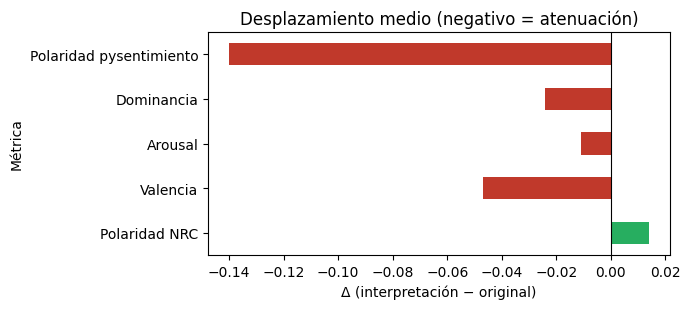

In [18]:
fig,ax=plt.subplots(figsize=(7,3.2)); t=tabla.set_index("Métrica")["Δ (TT-ST)"]
t.plot.barh(ax=ax, color=["#c0392b" if v<0 else "#27ae60" for v in t])
ax.axvline(0,color="k",lw=.8); ax.set_xlabel("Δ (interpretación − original)")
ax.set_title("Desplazamiento medio (negativo = atenuación)"); plt.tight_layout(); plt.show()

#### Distribuciones a nivel de segmento

Como complemento a la comparación anterior, que resumía cada discurso en una media, esta vista muestra la distribución completa de los segmentos, de modo que no solo se aprecia si
los valores cambian en promedio, sino cómo se reparten.

Cada panel corresponde a una métrica y superpone dos histogramas: el de los segmentos originales (ST, en azul) y el
de las interpretaciones (TT, en rojo). Las alturas están normalizadas para que ambas distribuciones sean comparables aunque el número de segmentos no sea idéntico, y la leyenda de cada panel recoge la media y la mediana de cada grupo.

Conviene tener presente que estas medias, calculadas sobre el conjunto de los segmentos, no coinciden exactamente con las de la prueba de Wilcoxon anterior, que se obtenían por discurso. Son dos formas de agregar los mismos datos, ambas válidas.

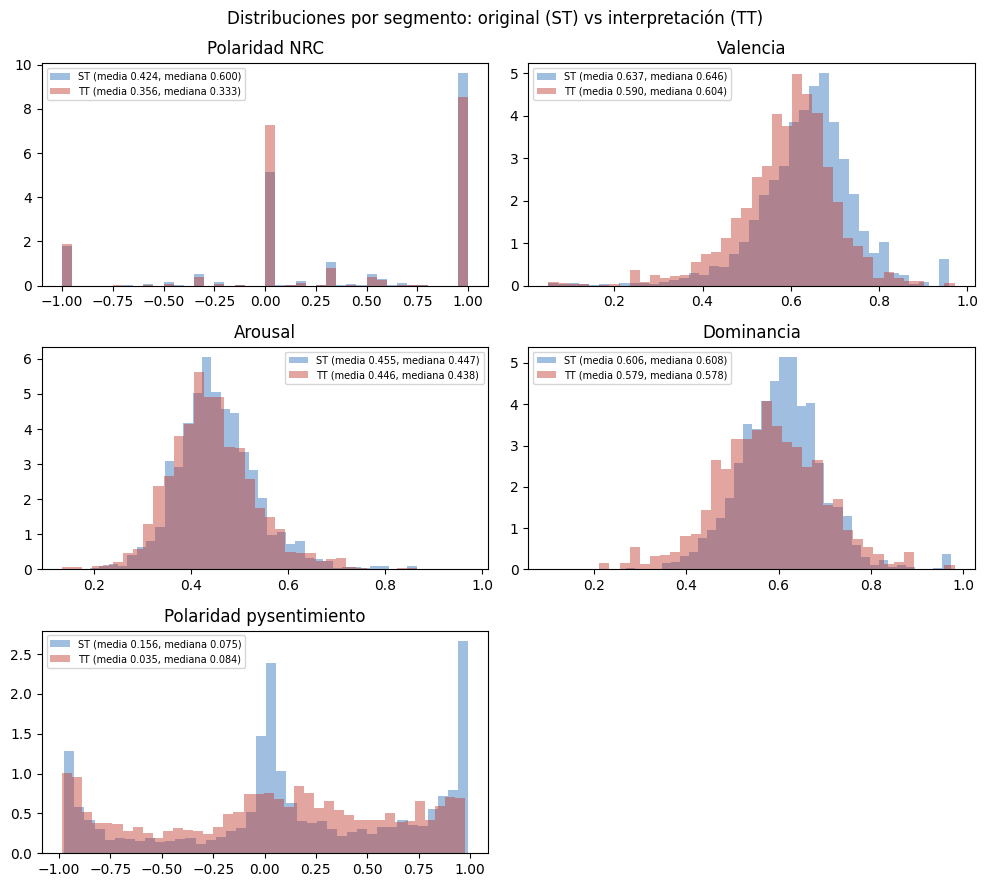

In [20]:
mets=[("nrc_polarity","Polaridad NRC"),("valence","Valencia"),("arousal","Arousal"),
    ("dominance","Dominancia"),("pysent_polarity","Polaridad pysentimiento")]
fig,axes=plt.subplots(3,2,figsize=(10,9))
for ax,(col,nom) in zip(axes.ravel(),mets):
    for role,color in (("ST","#2c6fbb"),("TT","#c0392b")):
        d=seg.loc[seg.role==role,col].dropna()
        ax.hist(d,bins=40,density=True,alpha=.45,color=color,
            label=f"{role} (media {d.mean():.3f}, mediana {d.median():.3f})")
    ax.set_title(nom); ax.legend(fontsize=7)
for ax in axes.ravel()[len(mets):]: ax.axis("off")  # oculta el panel sobrante de la rejilla 3x2
fig.suptitle("Distribuciones por segmento: original (ST) vs interpretación (TT)")
plt.tight_layout(); plt.show()

### 3.3 Desglose por estrato

La misma comparación entre original e interpretación se repite ahora dentro de cada uno de los dos estratos temáticos del subcorpus, para comprobar si el patrón se mantiene en ambos o depende del tipo de debate. El estrato I reúne los discursos de acción exterior y conflicto, y el estrato II los del Consejo Europeo y la orientación estratégica de la
Unión. Para cada métrica y cada estrato se indica el desplazamiento medio de la interpretación respecto al original (Δ TT-ST), el nivel de significación de la prueba de
Wilcoxon pareada dentro de ese estrato y el número de discursos (n) sobre el que se calcula.

In [22]:
for col,nom in [("pysent_polarity","Polaridad pysentimiento"),("nrc_polarity","Polaridad NRC"),
                ("valence","Valencia"),("arousal","Arousal"),("dominance","Dominancia")]:
    print(f"\n--- {nom} ---")
    for st_lab,g in disc.groupby("stratum"):
        d=g[[col+"_ST",col+"_TT"]].dropna()
        try: _,p=wilcoxon(d[col+"_ST"],d[col+"_TT"]); ps=f"p={p:.4f}"
        except Exception: ps="n/d"
        print(f"  Estrato {st_lab}: Δ={(d[col+'_TT']-d[col+'_ST']).mean():+.3f}  ({ps}, n={len(d)})")


--- Polaridad pysentimiento ---
  Estrato I: Δ=-0.134  (p=0.0000, n=47)
  Estrato II: Δ=-0.153  (p=0.0000, n=24)

--- Polaridad NRC ---
  Estrato I: Δ=-0.000  (p=0.9373, n=47)
  Estrato II: Δ=+0.042  (p=0.6431, n=24)

--- Valencia ---
  Estrato I: Δ=-0.045  (p=0.0000, n=47)
  Estrato II: Δ=-0.052  (p=0.0000, n=24)

--- Arousal ---
  Estrato I: Δ=-0.013  (p=0.0070, n=47)
  Estrato II: Δ=-0.008  (p=0.2643, n=24)

--- Dominancia ---
  Estrato I: Δ=-0.028  (p=0.0000, n=47)
  Estrato II: Δ=-0.015  (p=0.1005, n=24)


### 3.4 Acuerdo entre los dos métodos

La polaridad se ha medido de dos maneras distintas: con el léxico NRC y con pysentimiento. Conviene saber hasta qué punto coinciden, porque su grado de acuerdo informa sobre la
solidez de las medidas y sobre los límites de cada enfoque. La comparación se hace con dos indicadores: la correlación de Pearson, que mide en qué grado los dos métodos varían
juntos (de -1 a 1, cuanto más cerca de 1 más relacionados), y la coincidencia de signo, es decir, el porcentaje de segmentos en los que ambos clasifican la polaridad en el mismo
sentido (positivo, negativo o neutro).

En el gráfico, cada punto es un segmento: en el eje horizontal su polaridad según el NRC y en el vertical según pysentimiento. Las líneas en cero separan los cuadrantes, y los puntos situados donde ambos ejes comparten signo son aquellos en que los dos métodos coinciden. Que la polaridad NRC se distribuya en franjas verticales se debe a que toma
valores escalonados (es una proporción calculada por segmento), mientras que pysentimiento
varía de forma continua.

Correlación de Pearson: r=0.411 | coincidencia de signo: 57.5% (n=4872)


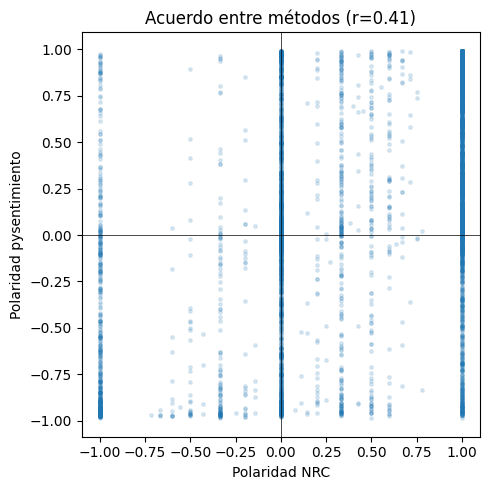

In [23]:
s=seg.dropna(subset=["pysent_polarity","nrc_polarity"]).copy()
r,_=pearsonr(s.nrc_polarity,s.pysent_polarity)
acuerdo=((np.sign(s.nrc_polarity)==np.sign(s.pysent_polarity))|
         ((s.nrc_polarity==0)&(s.pysent_polarity.abs()<0.05))).mean()
print(f"Correlación de Pearson: r={r:.3f} | coincidencia de signo: {acuerdo:.1%} (n={len(s)})")
fig,ax=plt.subplots(figsize=(5,5)); ax.scatter(s.nrc_polarity,s.pysent_polarity,s=6,alpha=.15)
ax.axhline(0,color="k",lw=.5); ax.axvline(0,color="k",lw=.5)
ax.set_xlabel("Polaridad NRC"); ax.set_ylabel("Polaridad pysentimiento")
ax.set_title(f"Acuerdo entre métodos (r={r:.2f})"); plt.tight_layout(); plt.show()

### 3.5 Palabras clave (keyness)

El análisis de palabras clave identifica los términos que resultan característicamente frecuentes en el subcorpus al compararlo con el corpus de referencia construido antes. La
medida empleada es el log-likelihood (Dunning, 1993): cuanto mayor es su valor, más se aparta la frecuencia observada de la que cabría esperar si ambos corpus se comportaran igual. El signo indica la dirección: positivo cuando la palabra es más frecuente en el subcorpus que en la referencia (sobrerrepresentada) y negativo en el caso contrario.

En la tabla, junto a cada palabra figuran su log-likelihood (ll) y su signo, las frecuencias absolutas en el subcorpus (f_sub) y en la referencia (f_ref), y esas mismas frecuencias normalizadas por cada 10.000 palabras (per10k_sub y per10k_ref), que permiten compararlas pese al distinto tamaño de los dos corpus. Estas palabras clave no son un fin en sí mismas, sino una vía para localizar los temas predominantes del subcorpus y orientar el análisis cualitativo posterior.

In [24]:
pd.DataFrame(kw.keyness(st_freq, st_total, ref_freq, ref_total, top=30))

,word,ll,sign,f_sub,f_ref,per10k_sub,per10k_ref
0,region,102.42,+,94,16,16.5,1.8
1,peace,102.28,+,78,8,13.7,0.9
2,israel,94.22,+,58,2,10.2,0.2
3,nuclear,92.41,+,60,3,10.5,0.3
4,palestinian,90.57,+,56,2,9.8,0.2
5,middle,83.24,+,60,5,10.5,0.6
6,arab,75.72,+,40,0,7.0,0.0
7,presidency,71.64,+,139,65,24.4,7.2
8,east,70.60,+,61,9,10.7,1.0
9,weapons,70.04,+,37,0,6.5,0.0


### 3.6 Colocaciones

Las colocaciones muestran las palabras que tienden a acompañar a un término dado con más frecuencia de la esperable por azar, lo que revela cómo se usa ese término y en qué campo semántico se inscribe dentro del subcorpus. El término examinado (el nodo) es aquí "rights", y puede sustituirse por cualquier otra palabra clave de 3.5 para explorar sus compañías. La fuerza de cada asociación se mide con dos índices habituales en lingüística de corpus: log-Dice (Sinclair, 1991; Stubbs, 2001), una medida estable y acotada, y la información mutua (MI), que tiende a destacar las combinaciones menos frecuentes.

En la tabla, f_coll es el número de veces que el colocado aparece junto al nodo y f_total su frecuencia total en el subcorpus; los resultados se ordenan de mayor a menor log-Dice.

Como en el caso de las palabras clave, las colocaciones sirven de guía para el análisis
cualitativo, no de resultado por sí solas.

In [25]:
pd.DataFrame(kw.collocations(segments, "rights", top=15))

,collocate,f_coll,f_total,log_dice,mi
0,human,50,57,13.64,9.46
1,respect,8,22,11.46,8.19
2,democracy,9,53,11.22,7.09
3,fundamental,5,13,10.93,8.27
4,law,6,38,10.82,6.98
5,democratisation,4,5,10.75,9.32
6,initiative,4,28,10.37,6.84
7,charter,3,5,10.34,8.91
8,women,4,31,10.33,6.69
9,environmental,3,12,10.21,7.65


Para contrastar la prosodia semántica del término en las dos lenguas, se calculan también las colocaciones de su equivalente en la interpretación. El nodo en español es "derechos" y se obtiene de los segmentos meta (TT).

Estas cifras deben leerse como orientativas, en coherencia con la cautela de la metodología: dado el tamaño reducido del subcorpus, las medidas de colocación tienen valor indicativo y el peso del análisis recae en la lectura de las concordancias. El término, además, puede repartirse entre variantes (derechos, derecho), algo que conviene tener presente al leer la lista.

In [27]:
pd.DataFrame(kw.collocations(segments, "derechos", role="TT", top=15))

,collocate,f_coll,f_total,log_dice,mi
0,humanos,43,44,13.67,9.60
1,respeto,7,11,11.58,8.98
2,fundamentales,6,9,11.40,9.04
3,democratización,5,6,11.19,9.37
4,democracia,8,49,11.18,7.01
5,los,57,944,10.86,5.58
6,protección,3,6,10.46,8.63
7,libertades,3,6,10.46,8.63
8,carta,3,8,10.42,8.21
9,defensa,3,10,10.38,7.89


### 3.7 Concordancias

Las concordancias muestran cada aparición del término en su contexto inmediato, con unas palabras a izquierda y derecha, en el formato habitual de palabra clave en contexto (KWIC).
Son la herramienta central de la lectura cualitativa: permiten examinar, uso por uso, cómo se emplea un término y cómo se reformula al interpretarlo. Cada fila localiza la aparición (speech_id y seg_index) y muestra el contexto izquierdo (left), el término (kwic) y el contexto derecho (right) en el original.

La columna aligned trae el segmento de la interpretación que se solapa temporalmente con ese fragmento del original. La alineación es aproximada, porque se basa en la coincidencia
de los tiempos: sirve para localizar el pasaje correspondiente en la interpretación, pero la comparación fina entre original e interpretación se realiza después mediante lectura cualitativa, no de forma automática.

In [26]:
pd.set_option("display.max_colwidth", 60)
pd.DataFrame(kw.concordances(segments, "rights", context=7, max_lines=12))

,speech_id,seg_index,left,kwic,right,aligned
0,11-02-04-m-047,30,non-proliferation on a similar level to human,rights,and the fight against terrorism,esto forma parte ahora de las negociaciones que están en...
1,12-02-04-m-016,5,administration have been unable to protect the,rights,of women,le quiero recordar que la opresión de la mujer afgana qu...
2,12-02-04-m-016,9,Human,Rights,Watch even reports many sexual assaults against,o sea que hay cada vez más mujeres en Afganistán que est...
3,12-02-04-m-016,15,I believe and so does Amnesty Human,Rights,Watch and the Revolutionary Association for Women,a mí me parece que todas las organizaciones que he citad...
4,12-02-04-m-020,2,political conditionality including demanding progress in...,rights,particularly women's rights to education and access,la Unión Europea es un gran donente donante lo que nos p...
5,12-02-04-m-020,2,demanding progress in human rights particularly women's,rights,to education and access to the workforce,la Unión Europea es un gran donente donante lo que nos p...
6,12-02-04-m-021,12,that this provision along with others establishing,rights,for women will actually help see rights,hay escaños reservados para la mujer en el Parlamento pe...
7,12-02-04-m-021,12,rights for women will actually help see,rights,for women being properly implemented and see,hay escaños reservados para la mujer en el Parlamento pe...
8,12-02-04-m-025,18,human,rights,is important particularly the situation of women,se piensa que se puede incorporar a los talibán en la en...
9,12-02-04-m-025,19,formal,rights,may well be given but they're unlikely,se piensa que se puede incorporar a los talibán en la en...


### 3.8 Selección de casos (criterio triangulado)

Este apartado localiza los casos que se examinarán de cerca en el análisis cualitativo, aplicando el criterio de selección triangulado descrito en el apartado 4.5.3. La triangulación combina tres vías, cada una en una celda: los discursos con mayor desplazamiento afectivo entre original e interpretación (medido sobre la polaridad), los segmentos en los que los dos métodos de puntuación más discrepan, y los segmentos que contienen un término clave cargado. Un caso resulta especialmente relevante cuando lo señalan varias de estas vías a la vez.

La primera celda ordena los discursos por la magnitud del desplazamiento de polaridad de la interpretación respecto al original; la segunda, los segmentos por el grado de desacuerdo entre el léxico NRC y pysentimiento; y la tercera recupera los segmentos del original que contienen un término dado (aquí "peace"), que puede sustituirse por cualquier
palabra clave de 3.5. En conjunto, estas vías acotan los fragmentos sobre los que se realiza la lectura pragmática y evaluativa.

In [30]:
top_disc=disc.dropna(subset=["pysent_polarity_delta"]).reindex(
    disc["pysent_polarity_delta"].abs().sort_values(ascending=False).index)
print("Discursos con mayor desplazamiento de polaridad:")
display(top_disc[["speech_id","stratum","speaker","pysent_polarity_delta","valence_delta"]].head(8))

Discursos con mayor desplazamiento de polaridad:


,speech_id,stratum,speaker,pysent_polarity_delta,valence_delta
22,12-02-04-p-127,I,"Tannock, Timothy Charles Ayrton",-0.3382,-0.1040
34,21-07-04-m-009,II,"Duff, Andrew",-0.3361,-0.1107
37,21-07-04-m-016,II,"De Rossa, Proinsias",-0.3284,-0.1002
39,21-07-04-m-019,II,"McDonald, Mary Lou",-0.3147,-0.0358
6,11-02-04-m-053,I,"Lucas, Caroline",-0.2897,-0.0160
43,21-07-04-m-027,II,"Allister, James Hugh",-0.2886,-0.1109
42,21-07-04-m-026,II,"de Brún, Bairbre",-0.2814,-0.0430
35,21-07-04-m-013,II,"Crowley, Brian",-0.2801,-0.0523


In [31]:
s=seg.dropna(subset=["pysent_polarity","nrc_polarity"]).copy()
s["desacuerdo"]=(s.nrc_polarity-s.pysent_polarity).abs()
print("Segmentos de mayor desacuerdo entre métodos:")
display(s.sort_values("desacuerdo",ascending=False)[
    ["speech_id","role","nrc_polarity","pysent_polarity","desacuerdo","text"]].head(10))

Segmentos de mayor desacuerdo entre métodos:


,speech_id,role,nrc_polarity,pysent_polarity,desacuerdo,text
941,12-02-04-m-020,TT,1.0,-0.9821,1.9821,me preocupa la falta de seguridad y la concentración de ...
3584,30-03-04-p-191,TT,1.0,-0.9722,1.9722,y yo señor Presidente estoy aquí en una situación muy co...
2402,21-07-04-m-005,TT,-1.0,0.9711,1.9711,y así lo hicimos en junio y el informe que se preparó ha...
2714,21-07-04-m-022,ST,1.0,-0.9706,1.9706,that apart the legacy on the constitutional front which ...
1701,21-04-04-m-056,TT,1.0,-0.9682,1.9682,y por último señor Presidente creo que no está a la altu...
3114,26-02-04-m-032,TT,-1.0,0.9675,1.9675,le damos la bienvenida a este informe que llega en muy b...
929,12-02-04-m-020,ST,1.0,-0.9675,1.9675,there have been significant regroupings of Taliban and A...
4566,31-03-04-m-043,TT,1.0,-0.9675,1.9675,francamente esto no es aceptable para el Parlamento Europeo
1691,21-04-04-m-056,TT,1.0,-0.9665,1.9665,los asesinatos ilegales de los últimos líderes palestino...
948,12-02-04-m-020,TT,1.0,-0.9631,1.9631,o sea que se que se queme y se pague a los a los agricul...


In [32]:
termino="peace"
mask=seg[(seg.role=="ST")].text.fillna("").str.contains(rf"\b{termino}\b", case=False)
print(f"Segmentos ST con '{termino}':")
display(seg[(seg.role=="ST")][mask][["speech_id","seg_index","nrc_polarity","valence","text"]].head(10))

Segmentos ST con 'peace':


,speech_id,seg_index,nrc_polarity,valence,text
252,11-02-04-m-046,5,1.000000,0.7742,the EU believes that all of our efforts should be aimed ...
276,11-02-04-m-046,29,1.000000,0.7562,they enhance global and regional peace and security
473,11-02-04-p-121,4,1.000000,0.7279,and as presidency we shall play an active role in in int...
488,11-02-04-p-121,19,1.000000,0.6413,these included the continued return of Palestinian polic...
491,11-02-04-p-121,22,0.333333,0.5849,Mr President there can be no doubt that the construction...
499,11-02-04-p-121,30,0.333333,0.5894,the decision to abstain was taken after intense consulta...
520,11-02-04-p-121,51,0.600000,0.7960,it might also serve to reassure Israel as to the wisdom ...
522,11-02-04-p-121,53,1.000000,0.7727,they should emphasise their desire for a comprehensive p...
524,11-02-04-p-121,55,0.714286,0.7045,a final finally Madam President I should like to assure ...
589,11-02-04-p-124,11,-0.333333,0.5708,Palestinians have to want peace and avoid terrorism


---

Una última nota sobre la reproducibilidad de los resultados. Las puntuaciones del léxico NRC son deterministas: cualquier reejecución de este cuaderno produce exactamente los mismos valores. Las de pysentimiento, en cambio, dependen del modelo que se descarga, de modo que pueden presentar pequeñas variaciones decimales si la versión del modelo no es idéntica a la empleada aquí. Esas diferencias no alteran los patrones ni las conclusiones
del análisis, pero conviene tenerlas presentes al comparar ejecuciones.